In [1]:
import os
import shutil
from datetime import datetime
import json

from scipy.optimize import curve_fit
from scipy.interpolate import interp1d



import h5py
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def backup_data(data_filename):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename_only = os.path.basename(data_filename)
    name, ext = os.path.splitext(filename_only)
    backup_name = f"{name}_{timestamp}{ext}"
    backup_path = os.path.join('data_backups', backup_name)
    shutil.copy2(data_filename, backup_path)

def save_nested_dict_to_hdf5(filename, data, save_backup=True):

    if save_backup:
        backup_data(filename)

    with h5py.File(filename, 'w') as f:
        def _save_dict(group, dictionary):
            for key, value in dictionary.items():
                if isinstance(value, dict):
                    subgroup = group.create_group(str(key))
                    _save_dict(subgroup, value)
                elif isinstance(value, np.ndarray):
                    group.create_dataset(key, data=value, compression='gzip')
                elif isinstance(value, list):
                    group.create_dataset(key, data=np.array(value), compression='gzip')
                else:
                    group.attrs[key] = value  # Store scalars as attributes
        
        _save_dict(f, data)

def update_data_file(filename, data, keys, save_backup=True):
    if save_backup:
        backup_data(filename)
    
    with h5py.File(filename, 'a') as f:  # Open in append mode
        def _navigate_to_parent(group, key_path):
            """Navigate to the parent group of the target location"""
            current_group = group
            for key in key_path[:-1]:  # All keys except the last one
                if str(key) in current_group:
                    current_group = current_group[str(key)]
                else:
                    # Create the group if it doesn't exist
                    current_group = current_group.create_group(str(key))
            return current_group
        
        def _save_data_at_location(group, key, value):
            """Save data at a specific location, replacing if it exists"""
            # Remove existing data if it exists
            if key in group:
                del group[key]
            
            # Save new data
            if isinstance(value, dict):
                subgroup = group.create_group(key)
                _save_dict(subgroup, value)
            elif isinstance(value, np.ndarray):
                group.create_dataset(key, data=value, compression='gzip')
            elif isinstance(value, list):
                group.create_dataset(key, data=np.array(value), compression='gzip')
            else:
                group.attrs[key] = value  # Store scalars as attributes
        
        def _save_dict(group, dictionary):
            """Helper function to save nested dictionaries"""
            for key, value in dictionary.items():
                _save_data_at_location(group, str(key), value)
        
        # Navigate to the parent location
        parent_group = _navigate_to_parent(f, keys)
        
        # Save the data at the final key location
        final_key = str(keys[-1])
        _save_data_at_location(parent_group, final_key, data)

In [3]:
def load_nested_dict_from_hdf5(filename):
    def _load_dict(group):
        result = {}
        for key in group.keys():
            if isinstance(group[key], h5py.Group):
                result[key] = _load_dict(group[key])
            else:
                result[key] = group[key][()]  # Load dataset
        
        # Load attributes (scalars)
        for key, value in group.attrs.items():
            result[key] = value
            
        return result
    
    with h5py.File(filename, 'r') as f:
        return _load_dict(f)

def print_tree(data, max_level=None):
    def __print_tree_recursive(root, level=0):
        if isinstance(root, dict):
            if not max_level is None and level == max_level:
                return
            level_str = '- '*level
            for key in root:
                print(f'{level_str}{key}')
                __print_tree_recursive(root[key], level+1)
    __print_tree_recursive(data)

# 1. Setup

In [4]:
# new_data = {}
# new_data['data'] = data

# save_nested_dict_to_hdf5(data_filename, new_data)

In [5]:
data_filename = 'current_correlations_data.h5'

data = load_nested_dict_from_hdf5(data_filename)

In [6]:
print_tree(data['data'], max_level=4)

coupling_point_1
- disordered
- - ((1, 2), (3, 4))
- - - population_difference
- - - times
- - - beamsplitter_time_guess
- - ((1, 2), (4, 5))
- - - population_difference
- - - times
- - - beamsplitter_time_guess
- - ((1, 2), (5, 6))
- - - population_difference
- - - times
- - - beamsplitter_time_guess
- - ((1, 2), (6, 7))
- - - population_difference
- - - times
- - - beamsplitter_time_guess
- - ((1, 2), (7, 8))
- - - population_difference
- - - times
- - - beamsplitter_time_guess
- - ((2, 3), (4, 5))
- - ((2, 3), (5, 6))
- - - population_difference
- - - times
- - - beamsplitter_time_guess
- - ((2, 3), (6, 7))
- - ((2, 3), (7, 8))
- - - population_difference
- - - times
- - - beamsplitter_time_guess
- - ((3, 4), (5, 6))
- - - population_difference
- - - times
- - - beamsplitter_time_guess
- - ((3, 4), (6, 7))
- - - population_difference
- - - times
- - - beamsplitter_time_guess
- - ((3, 4), (7, 8))
- - - population_difference
- - - times
- - - beamsplitter_time_guess
- - ((4, 5), (6, 7

In [7]:
coupling_point = 'coupling_point_5'

In [8]:
correlation_pairs = []

for i in range(1, 6):
    for j in range(i+2, 8):
        correlation_pairs.append(((i,i+1),(j,j+1)))

print(correlation_pairs)
print(len(correlation_pairs))

[((1, 2), (3, 4)), ((1, 2), (4, 5)), ((1, 2), (5, 6)), ((1, 2), (6, 7)), ((1, 2), (7, 8)), ((2, 3), (4, 5)), ((2, 3), (5, 6)), ((2, 3), (6, 7)), ((2, 3), (7, 8)), ((3, 4), (5, 6)), ((3, 4), (6, 7)), ((3, 4), (7, 8)), ((4, 5), (6, 7)), ((4, 5), (7, 8)), ((5, 6), (7, 8))]
15


### 1.1 Load Config

In [9]:
config_filename = 'current_correlations_config.json'

with open(config_filename, 'r') as f:
    config = json.load(f)


coupling_point_config = config[coupling_point]

print(coupling_point_config.keys())


dict_keys(['simulation_config', 'data_config', 'coupling', 'coupling_error', 'T2s'])


### 1.2 Extract Data

In [10]:
correlation_pair_to_population_difference = {}
correlation_pair_to_population_times = {}

In [11]:
for correlation_pair in correlation_pairs:

    # check if data exists 'disordered' state

    # there's also a flag to specify which state data to use, default is disordered, but can be overridden to be highest instead

    state_to_use = 'disordered'
    if 'beamsplitter_fit' in coupling_point_config['data_config'][str(correlation_pair)]:
        state_to_use = coupling_point_config['data_config'][str(correlation_pair)]['beamsplitter_fit']
        # print(f'found beamsplitter fit: {state_to_use}')

    use_disordered = False

    if 'disordered' in state_to_use:

        disoreded_in_dict = 'disordered' in data['data'][coupling_point]
        correlation_pair_in_dict = disoreded_in_dict and str(correlation_pair) in data['data'][coupling_point]['disordered']
        data_in_dict = disoreded_in_dict and correlation_pair_in_dict and len(data['data'][coupling_point]['disordered'][str(correlation_pair)]) > 0

        # print(f'disoreded_in_dict: {disoreded_in_dict}')
        # print(f'correlation_pair_in_dict: {correlation_pair_in_dict}')
        # print(f'data_in_dict: {data_in_dict}')

        if data_in_dict:
            use_disordered = True
            
            

    if use_disordered:
        # use disordered data
        print(f'using disordered state for correlation pair {correlation_pair}')
        correlation_pair_data = data['data'][coupling_point]['disordered'][str(correlation_pair)]
        beamsplitter_time_guess = correlation_pair_data['beamsplitter_time_guess']
    else:
        # use highest data
        print(f'using highest state for correlation pair {correlation_pair}')
        correlation_pair_data = data['data'][coupling_point]['highest'][str(correlation_pair)]
        beamsplitter_time_guess = correlation_pair_data['beamsplitter_time']

    times = correlation_pair_data['times']
    population_difference = correlation_pair_data['population_difference']

    correlation_pair_to_population_difference[correlation_pair] = population_difference
    correlation_pair_to_population_times[correlation_pair] = times



using highest state for correlation pair ((1, 2), (3, 4))
using disordered state for correlation pair ((1, 2), (4, 5))
using highest state for correlation pair ((1, 2), (5, 6))
using disordered state for correlation pair ((1, 2), (6, 7))
using disordered state for correlation pair ((1, 2), (7, 8))
using disordered state for correlation pair ((2, 3), (4, 5))
using disordered state for correlation pair ((2, 3), (5, 6))
using disordered state for correlation pair ((2, 3), (6, 7))
using disordered state for correlation pair ((2, 3), (7, 8))
using highest state for correlation pair ((3, 4), (5, 6))
using highest state for correlation pair ((3, 4), (6, 7))
using highest state for correlation pair ((3, 4), (7, 8))
using disordered state for correlation pair ((4, 5), (6, 7))
using disordered state for correlation pair ((4, 5), (7, 8))
using highest state for correlation pair ((5, 6), (7, 8))


### 1.3 Plot Population Differences

In [12]:
# for correlation_pair in correlation_pairs:

#     population_difference = correlation_pair_to_population_difference[correlation_pair]
#     times = correlation_pair_to_population_times[correlation_pair]

#     # create two plots stacked vertically
#     fig, axs = plt.subplots(2, 1, figsize=(8, 10))

#     axs = axs.flatten()
#     for i in range(len(axs)):


#         axs[i].plot(times, population_difference[i,:], linestyle='', marker='o')

#         axs[i].axvline(beamsplitter_time_guess, color='r', alpha=0.4, linestyle='--', label='Beamsplitter Time guess')
    
#         axs[i].set_xlabel('Time (ns)')
#         axs[i].set_ylabel('Population')
#         axs[i].set_title(f'Population Difference for rung {correlation_pair[i]}')
#         axs[i].legend()

#         axs[i].set_ylim(-1, 1)

#     plt.suptitle(f'Population Differences for Rungs {correlation_pair[0]} and {correlation_pair[1]}')

#     plt.show()

# 2. Fit Beamsplitters

In [13]:
def cos_fit(t, A, omega, phi, offset, T2):
    return A * np.cos(omega * t + phi) * np.exp(-t/T2) + offset

In [14]:
correlation_pair_to_beamsplitter_dict = {}

correlation_pair_to_beamsplitter_dict = {correlation_pair: {} for correlation_pair in correlation_pairs}

In [15]:
correlation_pairs_to_fit = correlation_pairs

# correlation_pairs_to_fit = []
# correlation_pairs_to_fit.append(((3,4),(5,6)))
# correlation_pairs_to_fit.append(((4,5),(7,8)))
# correlation_pairs_to_fit.append(((4,5),(6,7)))
# correlation_pairs_to_fit.append(((2,3),(4,5)))

In [16]:
# initial guess: [A, omega, phi, offset, T2]

initial_guess_dict = {
    ((4,5),(7,8)): ([-0.05, 84.34, 1.5, 0.03, 0.18], 
                    [])
}

initial_guess_dict = {}

correlation_pair: ((1, 2), (3, 4))
coupling strength 1: 6.3 MHz
coupling strength 2: 6.69 MHz
beamsplitter_time_1: 20.0 ns +/- 0.126 ns
beamsplitter_time_2: 19.0 ns +/- 0.168 ns
using average coupling strength for correlation pair ((1, 2), (3, 4))
final beamsplitter time: 19.26 ns +/- 0.105 ns
correlation_pair: ((1, 2), (4, 5))
Using negative amp initial guess
initial bs time: 0.03796583774588522
amp: 0.07
frequency: 98.78
phase: -2.18
offset: -0.03
T2: 38768.75


<>:114: SyntaxWarning: invalid escape sequence '\m'
<>:114: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Matt\AppData\Local\Temp\ipykernel_24708\852607841.py:114: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('t ($\mu$s)')


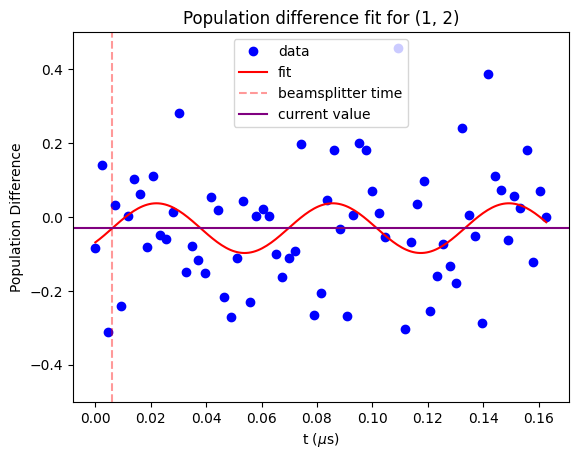

Fitted beamsplitter time for rung (1, 2): 6.16 ns ± 5.92 ns
Using negative amp initial guess
initial bs time: 0.016429171407495644
amp: -0.32
frequency: 67.52
phase: 0.46
offset: -0.17
T2: 321703.56


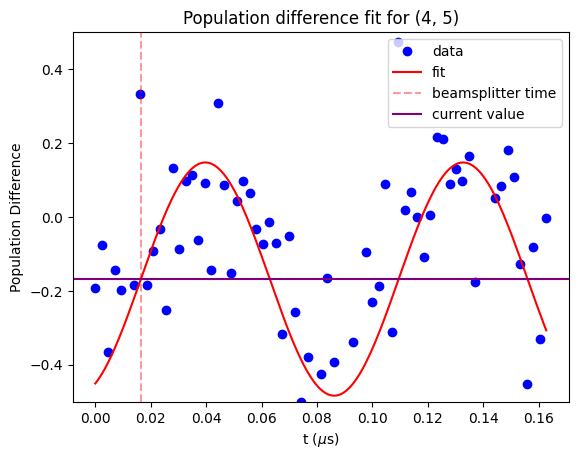

Fitted beamsplitter time for rung (4, 5): 16.43 ns ± 4.31 ns
using fitted beamsplitter time 2 for correlation pair ((1, 2), (4, 5))
final beamsplitter time: 16.43 ns +/- 4.311 ns
correlation_pair: ((1, 2), (5, 6))
coupling strength 1: 6.3 MHz
coupling strength 2: 6.59 MHz
beamsplitter_time_1: 20.0 ns +/- 0.126 ns
beamsplitter_time_2: 19.0 ns +/- 0.115 ns
using average coupling strength for correlation pair ((1, 2), (5, 6))
final beamsplitter time: 19.4 ns +/- 0.085 ns
correlation_pair: ((1, 2), (6, 7))
initial bs time: 0.05049780233226873
amp: 0.08
frequency: 83.98
phase: -2.67
offset: 0.16
T2: 1152800.93


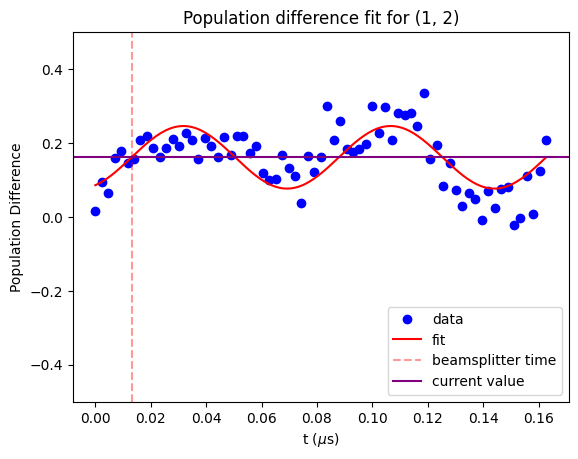

Fitted beamsplitter time for rung (1, 2): 13.09 ns ± 1.60 ns
initial bs time: 0.023938420214810473
amp: 0.11
frequency: 78.74
phase: -0.31
offset: 0.01
T2: 320814.92


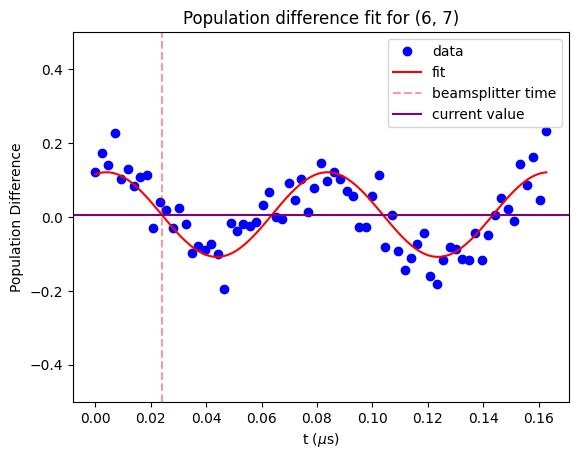

Fitted beamsplitter time for rung (6, 7): 23.94 ns ± 1.74 ns
using average fitted beamsplitter time for correlation pair ((1, 2), (6, 7))
final beamsplitter time: 18.51 ns +/- 1.182 ns
correlation_pair: ((1, 2), (7, 8))
Using negative amp initial guess
initial bs time: 0.03205933172411188
amp: -0.38
frequency: 64.87
phase: -0.51
offset: 0.07
T2: 0.09


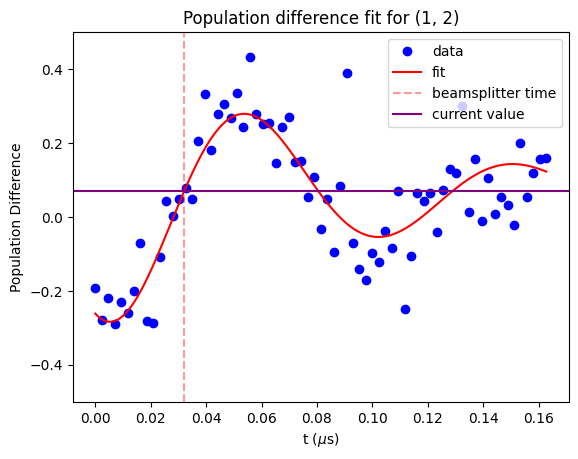

Fitted beamsplitter time for rung (1, 2): 32.06 ns ± 1.58 ns
Using negative amp initial guess
initial bs time: 0.024909125309472226
amp: -0.33
frequency: 82.76
phase: -0.49
offset: 0.03
T2: 0.54


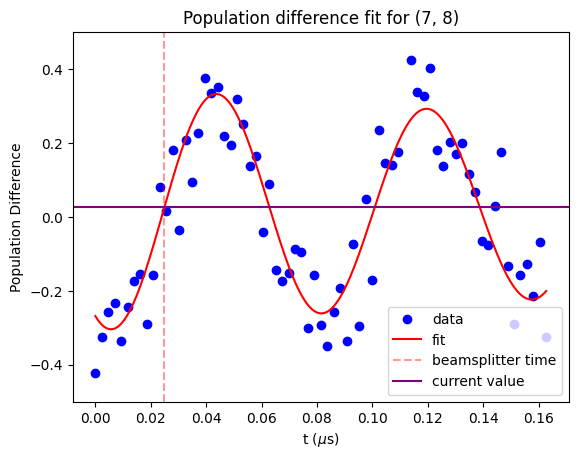

Fitted beamsplitter time for rung (7, 8): 24.91 ns ± 1.27 ns
using average fitted beamsplitter time for correlation pair ((1, 2), (7, 8))
final beamsplitter time: 28.48 ns +/- 1.014 ns
correlation_pair: ((2, 3), (4, 5))
Using negative amp initial guess
initial bs time: 0.0054032660280017054
amp: -0.27
frequency: 82.74
phase: 1.12
offset: -0.01
T2: 1.2


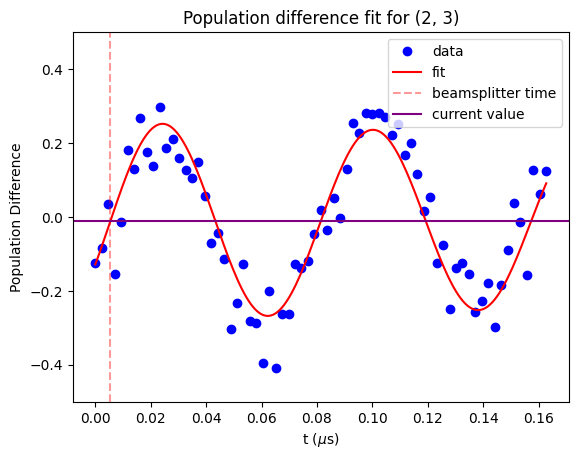

Fitted beamsplitter time for rung (2, 3): 5.40 ns ± 1.02 ns
Using negative amp initial guess
initial bs time: 0.021677420260873735
amp: -0.2
frequency: 67.42
phase: 0.11
offset: -0.08
T2: 5.4


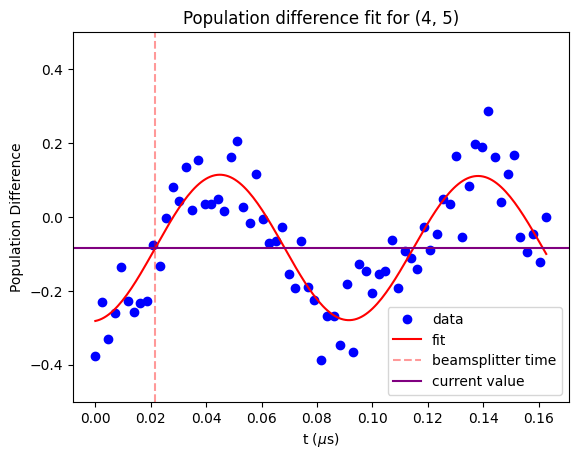

Fitted beamsplitter time for rung (4, 5): 21.68 ns ± 1.68 ns
using fitted beamsplitter time 2 for correlation pair ((2, 3), (4, 5))
final beamsplitter time: 21.68 ns +/- 1.676 ns
correlation_pair: ((2, 3), (5, 6))
Using negative amp initial guess
initial bs time: 0.0036384733024872416
amp: -0.24
frequency: 86.51
phase: 1.26
offset: -0.14
T2: 857171.53


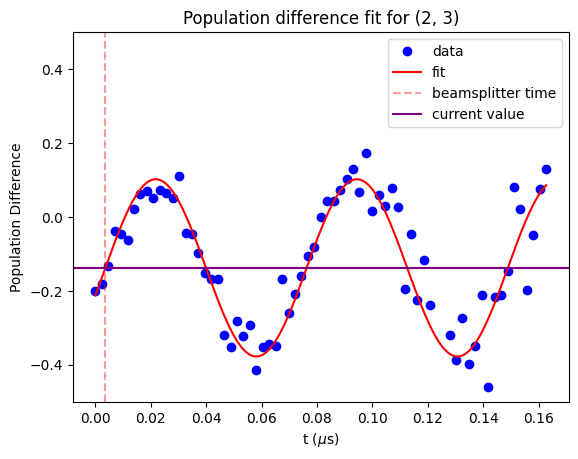

Fitted beamsplitter time for rung (2, 3): 3.64 ns ± 1.23 ns
initial bs time: 0.017288367722704753
amp: 0.08
frequency: 72.82
phase: 0.31
offset: -0.09
T2: 0.07


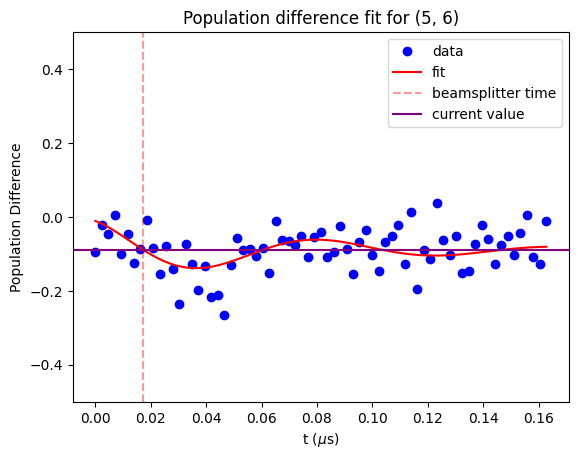

Fitted beamsplitter time for rung (5, 6): 17.29 ns ± 4.08 ns
using fitted beamsplitter time 2 for correlation pair ((2, 3), (5, 6))
final beamsplitter time: 17.29 ns +/- 4.077 ns
correlation_pair: ((2, 3), (6, 7))
Using negative amp initial guess
initial bs time: 0.005403266029063651
amp: -0.27
frequency: 82.74
phase: 1.12
offset: -0.01
T2: 1.2


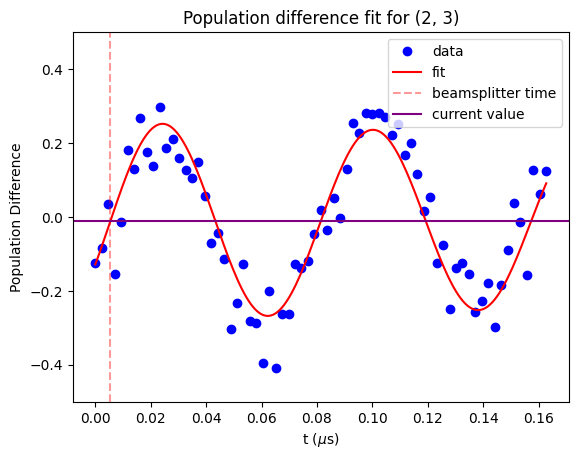

Fitted beamsplitter time for rung (2, 3): 5.40 ns ± 1.02 ns
Using negative amp initial guess
initial bs time: 0.02326593694737413
amp: 0.1
frequency: 93.25
phase: -0.6
offset: 0.01
T2: 0.08


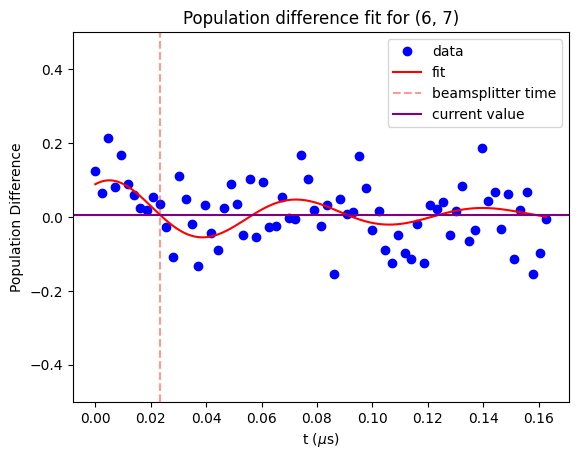

Fitted beamsplitter time for rung (6, 7): 23.27 ns ± 3.48 ns
using fitted beamsplitter time 2 for correlation pair ((2, 3), (6, 7))
final beamsplitter time: 23.27 ns +/- 3.477 ns
correlation_pair: ((2, 3), (7, 8))
Using negative amp initial guess
initial bs time: 0.00022923147913023268
amp: -0.17
frequency: 88.8
phase: 1.55
offset: -0.14
T2: 433977.45


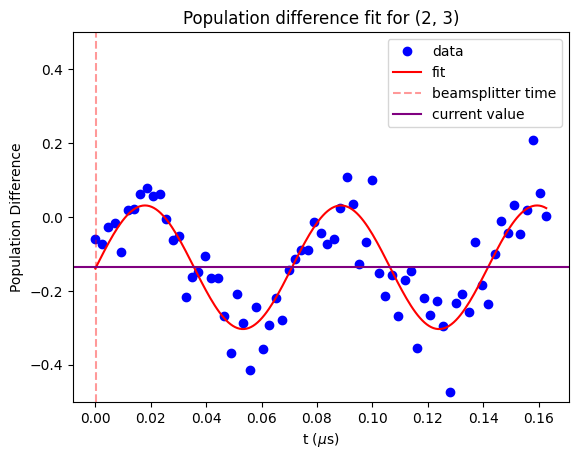

Fitted beamsplitter time for rung (2, 3): 0.23 ns ± 1.60 ns
Using negative amp initial guess
initial bs time: 0.01521047386942287
amp: -0.52
frequency: 87.83
phase: 0.23
offset: 0.03
T2: 1970821.83


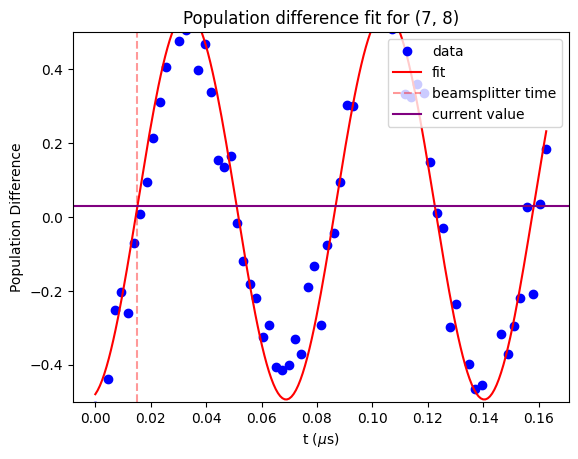

Fitted beamsplitter time for rung (7, 8): 15.21 ns ± 0.68 ns
using fitted beamsplitter time 2 for correlation pair ((2, 3), (7, 8))
final beamsplitter time: 15.21 ns +/- 0.683 ns
correlation_pair: ((3, 4), (5, 6))
coupling strength 1: 6.69 MHz
coupling strength 2: 6.59 MHz
beamsplitter_time_1: 19.0 ns +/- 0.168 ns
beamsplitter_time_2: 19.0 ns +/- 0.115 ns
using average coupling strength for correlation pair ((3, 4), (5, 6))
final beamsplitter time: 18.83 ns +/- 0.102 ns
correlation_pair: ((3, 4), (6, 7))
coupling strength 1: 6.69 MHz
coupling strength 2: 6.74 MHz
beamsplitter_time_1: 19.0 ns +/- 0.168 ns
beamsplitter_time_2: 19.0 ns +/- 0.028 ns
using average coupling strength for correlation pair ((3, 4), (6, 7))
final beamsplitter time: 18.62 ns +/- 0.085 ns
correlation_pair: ((3, 4), (7, 8))
coupling strength 1: 6.69 MHz
coupling strength 2: 6.39 MHz
beamsplitter_time_1: 19.0 ns +/- 0.168 ns
beamsplitter_time_2: 20.0 ns +/- 0.031 ns
using average coupling strength for correlation pa

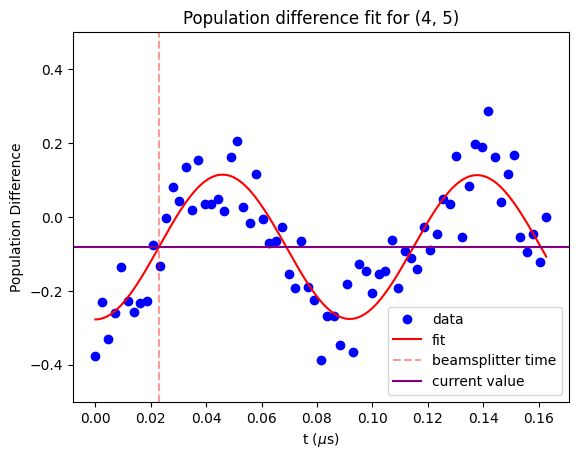

Fitted beamsplitter time for rung (4, 5): 22.97 ns ± 2.56 ns
Using negative amp initial guess
initial bs time: 0.023266685305337147
amp: 0.1
frequency: 93.25
phase: -0.6
offset: 0.01
T2: 0.08


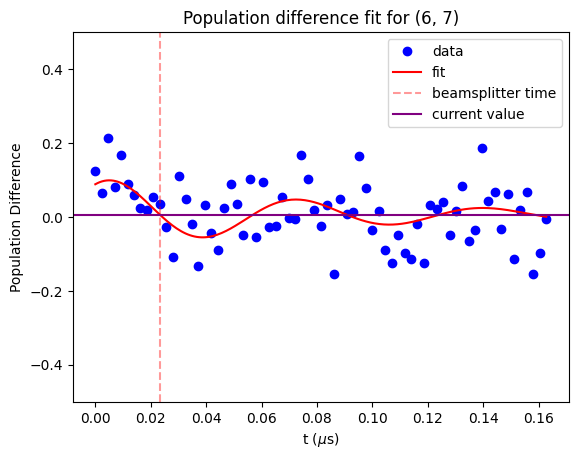

Fitted beamsplitter time for rung (6, 7): 23.27 ns ± 3.48 ns
using average fitted beamsplitter time for correlation pair ((4, 5), (6, 7))
final beamsplitter time: 23.12 ns +/- 2.159 ns
correlation_pair: ((4, 5), (7, 8))
Using negative amp initial guess
initial bs time: 0.013714710939815584
amp: -0.13
frequency: 64.48
phase: 0.69
offset: -0.12
T2: 783777.99


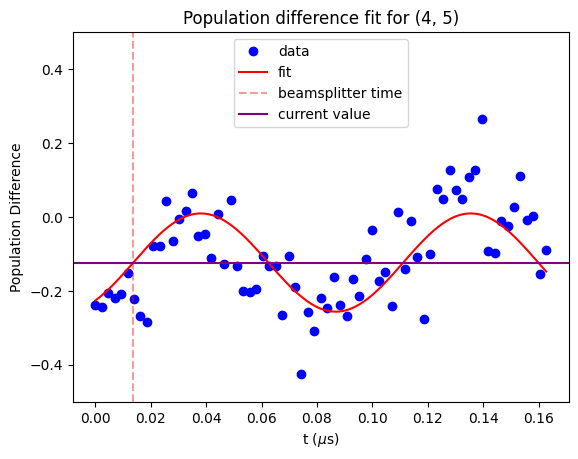

Fitted beamsplitter time for rung (4, 5): 13.71 ns ± 3.15 ns
Using negative amp initial guess
initial bs time: 0.016466663383762098
amp: -0.49
frequency: 73.44
phase: 0.36
offset: 0.09
T2: 0.65


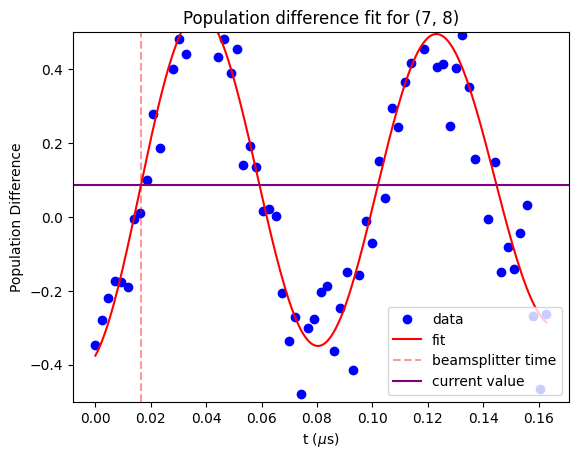

Fitted beamsplitter time for rung (7, 8): 16.47 ns ± 1.02 ns
using average fitted beamsplitter time for correlation pair ((4, 5), (7, 8))
final beamsplitter time: 15.09 ns +/- 1.658 ns
correlation_pair: ((5, 6), (7, 8))
coupling strength 1: 6.59 MHz
coupling strength 2: 6.39 MHz
beamsplitter_time_1: 19.0 ns +/- 0.115 ns
beamsplitter_time_2: 20.0 ns +/- 0.031 ns
using average coupling strength for correlation pair ((5, 6), (7, 8))
final beamsplitter time: 19.26 ns +/- 0.06 ns


In [17]:
plot_initial_guess = False

use_coupling_strength_for_all = False

for correlation_pair in correlation_pairs_to_fit:

    print(f'correlation_pair: {correlation_pair}')

    population_difference = correlation_pair_to_population_difference[correlation_pair]
    times = correlation_pair_to_population_times[correlation_pair]

    times_mus = times * 1e-3  # convert to microseconds

    start_cutoff = 0

    state_to_use = 'disordered'
    if 'beamsplitter_fit' in coupling_point_config['data_config'][str(correlation_pair)]:
        state_to_use = coupling_point_config['data_config'][str(correlation_pair)]['beamsplitter_fit']
    if 'coupling' in state_to_use:
        fit = False
    else:
        fit = True

    if fit and not use_coupling_strength_for_all:

        # iterate over two pairs in each correlation_pair
        for i in range(population_difference.shape[0]):

            coupling_MHz = abs(coupling_point_config['coupling'][f'J_{correlation_pair[i][0]}{correlation_pair[i][1]}'])

            offset_guess = np.mean(population_difference)
            amplitude_guess = (np.max(population_difference) - np.min(population_difference)) / 2
            frequency_guess = 2 * coupling_MHz * 2 * np.pi

            if correlation_pair in initial_guess_dict and not initial_guess_dict[correlation_pair][i] is None and len(initial_guess_dict[correlation_pair][i]) > 0:
                initial_guess = initial_guess_dict[correlation_pair][i]
            else:

                initial_guess = [amplitude_guess, frequency_guess, 0, offset_guess, 5]

                # compare mean squared error for original vs phase-shifted (pi) initial guesses
                pred_orig = cos_fit(times_mus, *initial_guess)
                mse_orig = np.mean((population_difference - pred_orig)**2)

                initial_guess_neg = initial_guess.copy()
                initial_guess_neg[0] *= -1
                pred_pi = cos_fit(times_mus, *initial_guess_neg)
                mse_pi = np.mean((population_difference - pred_pi)**2)

                if mse_pi < mse_orig:
                    initial_guess = initial_guess_neg
                    print('Using negative amp initial guess')


            bounds = ((-2*amplitude_guess, 0, -np.pi, -1, 0), (2*amplitude_guess, 4*frequency_guess, np.pi, 1, np.inf))

            # fit

            popt, pcov = curve_fit(cos_fit, times_mus[start_cutoff:], population_difference[i][start_cutoff:], p0=initial_guess, bounds=bounds)
            
            amp, frequency, phase, offset, T2 = popt
            perr = np.sqrt(np.diag(pcov))

            beamsplitter_time = (np.pi/2 - phase)/frequency
            print(f'initial bs time: {beamsplitter_time}')
            while beamsplitter_time < 0:
                beamsplitter_time += np.pi/frequency

            while beamsplitter_time > np.pi/frequency:
                beamsplitter_time -= np.pi/frequency

            # error propogation

            # Extract individual parameter errors
            frequency_err = perr[1]  # frequency is index 1
            phase_err = perr[2]      # phase is index 2

            # Get covariance between frequency and phase
            freq_phase_covariance = pcov[1, 2]


            # Error propagation for t_BS = f(phase, frequency) = (π/2 - phase)/frequency
            df_dphase = -1/frequency
            df_dfrequency = -(np.pi/2 - phase)/(frequency**2)


            # Error propagation formula, unchanged by while loops
            beamsplitter_time_err = np.sqrt(
                (df_dphase**2) * (phase_err**2) +
                (df_dfrequency**2) * (frequency_err**2) +
                2 * df_dphase * df_dfrequency * freq_phase_covariance
            )

            print(f'amp: {round(amp,2)}')
            print(f'frequency: {round(frequency,2)}')
            print(f'phase: {round(phase,2)}')
            print(f'offset: {round(offset,2)}')
            print(f'T2: {round(T2,2)}')


            fit_times = np.linspace(times_mus[0], times_mus[-1], 201)

            plt.plot(times_mus, population_difference[i], linestyle='', color='blue', marker='o', label='data')
            plt.plot(fit_times, cos_fit(fit_times, *popt), color='red', label='fit')
            if plot_initial_guess:
                print(f'x0: {list(initial_guess)}')
                print(f'popt rounded: {list(np.round(popt, 2))}')
                plt.plot(fit_times, cos_fit(fit_times, *initial_guess), label='initial guess')

            plt.axvline(x=beamsplitter_time, color='red', linestyle='--', label='beamsplitter time', alpha=0.4)

            plt.axhline(y=offset, color='purple', label='current value')

            plt.xlabel('t ($\mu$s)')
            plt.ylabel('Population Difference')


            plt.title(f'Population difference fit for {correlation_pair[i]}')

            plt.ylim(-0.5, 0.5)

            plt.legend()
            plt.show()

            print(f'Fitted beamsplitter time for rung {correlation_pair[i]}: {beamsplitter_time*1e3:.2f} ns ± {beamsplitter_time_err*1e3:.2f} ns')
        
    
            correlation_pair_to_beamsplitter_dict[correlation_pair][f'beamsplitter_time_{i+1}'] = beamsplitter_time * 1e3 # ns
            correlation_pair_to_beamsplitter_dict[correlation_pair][f'beamsplitter_time_{i+1}_error'] = beamsplitter_time_err * 1e3 # ns

        
        beamsplitter_time_1 = correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_1']
        beamsplitter_time_2 = correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_2']

        beamsplitter_time_1_error = correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_1_error']
        beamsplitter_time_2_error = correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_2_error']
        
        state_to_use_index = None
        if '_' in state_to_use:
            state_to_use_index = state_to_use.split('_')[1]
            try:
                state_to_use_index = int(state_to_use_index)
            except ValueError:
                print(f'beamsplitter fit state to use not correct format, given: {state_to_use_index}, defaulting to average disordered')
                state_to_use = 'disordered'


        if state_to_use_index is None:
            print(f'using average fitted beamsplitter time for correlation pair {correlation_pair}')
            beamsplitter_time_average = (beamsplitter_time_1 + beamsplitter_time_2)/2
            beamsplitter_time_average_error = np.sqrt(beamsplitter_time_1_error**2 + beamsplitter_time_2_error**2) / 2
        elif state_to_use_index == 1:
            print(f'using fitted beamsplitter time 1 for correlation pair {correlation_pair}')
            beamsplitter_time_average = beamsplitter_time_1
            beamsplitter_time_average_error = beamsplitter_time_1_error
        elif state_to_use_index == 2:
            print(f'using fitted beamsplitter time 2 for correlation pair {correlation_pair}')
            beamsplitter_time_average = beamsplitter_time_2
            beamsplitter_time_average_error = beamsplitter_time_2_error

        print(f'final beamsplitter time: {np.round(beamsplitter_time_average, 2)} ns +/- {np.round(beamsplitter_time_average_error, 3)} ns')

        correlation_pair_to_beamsplitter_dict[correlation_pair][f'beamsplitter_time_average'] = beamsplitter_time_average
        correlation_pair_to_beamsplitter_dict[correlation_pair][f'beamsplitter_time_average_error'] = beamsplitter_time_average_error


    else:
        # use coupling strength
        coupling_MHz_1 = abs(coupling_point_config['coupling'][f'J_{correlation_pair[0][0]}{correlation_pair[0][1]}'])
        coupling_MHz_2 = abs(coupling_point_config['coupling'][f'J_{correlation_pair[1][0]}{correlation_pair[1][1]}'])

        coupling_MHz_1_error = abs(coupling_point_config['coupling_error'][f'J_{correlation_pair[0][0]}{correlation_pair[0][1]}'])
        coupling_MHz_2_error = abs(coupling_point_config['coupling_error'][f'J_{correlation_pair[1][0]}{correlation_pair[1][1]}'])

        beamsplitter_time_1 = np.pi/(4*coupling_MHz_1 * 2 * np.pi) * 1e3 # ns
        beamsplitter_time_2 = np.pi/(4*coupling_MHz_2 * 2 * np.pi) * 1e3 # ns

        beamsplitter_time_1_error = coupling_MHz_1_error / (8 * coupling_MHz_1**2) * 1e3  # ns
        beamsplitter_time_2_error = coupling_MHz_2_error / (8 * coupling_MHz_2**2) * 1e3  # ns

        print(f'coupling strength 1: {coupling_MHz_1} MHz')
        print(f'coupling strength 2: {coupling_MHz_2} MHz')

        print(f'beamsplitter_time_1: {np.round(beamsplitter_time_1)} ns +/- {np.round(beamsplitter_time_1_error, 3)} ns')
        print(f'beamsplitter_time_2: {np.round(beamsplitter_time_2)} ns +/- {np.round(beamsplitter_time_2_error, 3)} ns')

        correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_1'] = beamsplitter_time_1 # ns
        correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_2'] = beamsplitter_time_2 # ns
        correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_1_error'] = beamsplitter_time_1_error # ns
        correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_2_error'] = beamsplitter_time_2_error # ns



        if state_to_use == 'coupling':
            print(f'using average coupling strength for correlation pair {correlation_pair}')
            beamsplitter_time_average = (beamsplitter_time_1 + beamsplitter_time_2)/2
            beamsplitter_time_average_error = np.sqrt(beamsplitter_time_1_error**2 + beamsplitter_time_2_error**2) / 2
        elif state_to_use == 'coupling_1':
            print(f'using coupling strength 1 for correlation pair {correlation_pair}')
            beamsplitter_time_average = beamsplitter_time_1
            beamsplitter_time_average_error = beamsplitter_time_1_error
        elif state_to_use == 'coupling_2':
            print(f'using coupling strength 2 for correlation pair {correlation_pair}')
            beamsplitter_time_average = beamsplitter_time_2
            beamsplitter_time_average_error = beamsplitter_time_2_error

        print(f'final beamsplitter time: {np.round(beamsplitter_time_average, 2)} ns +/- {np.round(beamsplitter_time_average_error, 3)} ns')

        correlation_pair_to_beamsplitter_dict[correlation_pair][f'beamsplitter_time_average'] = beamsplitter_time_average
        correlation_pair_to_beamsplitter_dict[correlation_pair][f'beamsplitter_time_average_error'] = beamsplitter_time_average_error



In [18]:
print(correlation_pair_to_beamsplitter_dict[((4,5),(6,7))].keys())
# print(correlation_pair_to_beamsplitter_dict[((4,5),(6,7))]['beamsplitter_time_average'])

dict_keys(['beamsplitter_time_1', 'beamsplitter_time_1_error', 'beamsplitter_time_2', 'beamsplitter_time_2_error', 'beamsplitter_time_average', 'beamsplitter_time_average_error'])


# 3. Calculate Current Correlation

In [ ]:
def get_interpolation_value(times, current_correlation, beamsplitter_time, beamsplitter_error, plot_interpolation=False):

    interpolation_func = interp1d(times, current_correlation, kind='linear', fill_value="extrapolate")
    
    current_correlation_value = interpolation_func(beamsplitter_time)
    
    # Calculate derivative using interpolation at nearby points
    dt_small = 0.1  # small time step for derivative calculation
    if beamsplitter_time + dt_small <= times[-1] and beamsplitter_time - dt_small >= times[0]:
        derivative = (interpolation_func(beamsplitter_time + dt_small) - 
                    interpolation_func(beamsplitter_time - dt_small)) / (2 * dt_small)
    else:
        # Fall back to numerical derivative at nearest index
        beamsplitter_index = np.argmin(np.abs(times - beamsplitter_time))
        dt = times[1] - times[0]
        if beamsplitter_index > 0 and beamsplitter_index < len(current_correlation) - 1:
            derivative = (current_correlation[beamsplitter_index + 1] - current_correlation[beamsplitter_index - 1]) / (2 * dt)
        else:
            derivative = 0  # or handle edge case differently

    # Error propagation
    beamsplitter_error = correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_average_error']
    current_correlation_error = abs(derivative) * beamsplitter_error


    if plot_interpolation:
        fit_times = np.linspace(times[0], times[-1], 501)
        plt.plot(times, current_correlation, linestyle='', marker='o', label='data')
        plt.plot(fit_times, interpolation_func(fit_times), label='interpolation')
        
        plt.axvline(x=beamsplitter_time, color='red', linestyle='--', label='beamsplitter time', alpha=0.4)
        plt.axhline(y=current_correlation_value, color='purple', linestyle='--', label='current correlation value', alpha=0.4)

        plt.legend()

        plt.xlabel('Time (ns)')
        plt.ylabel('Current Correlation')

        plt.ylim(-10, 10)
        
        plt.title(f'Current Correlation for {correlation_pair}')

        plt.show()

    return current_correlation_value, current_correlation_error


In [20]:
correlation_pair_to_current_correlation_value = {}
correlation_pair_to_current_correlation_error = {}

((1, 2), (3, 4)): beamsplitter_average: 19.26 ns


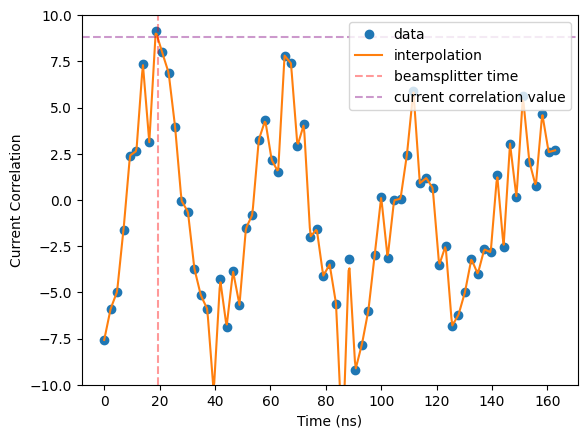

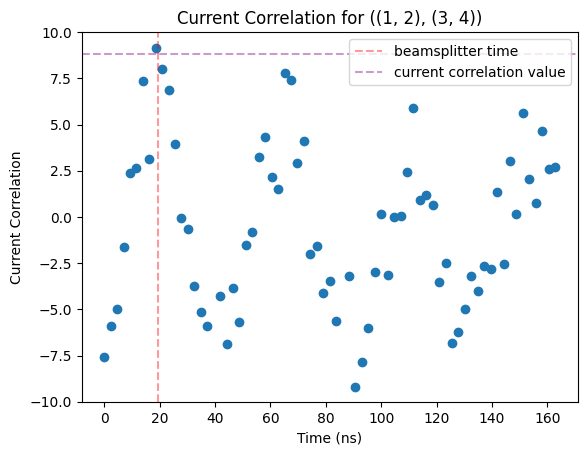

((1, 2), (4, 5)): beamsplitter_average: 16.43 ns


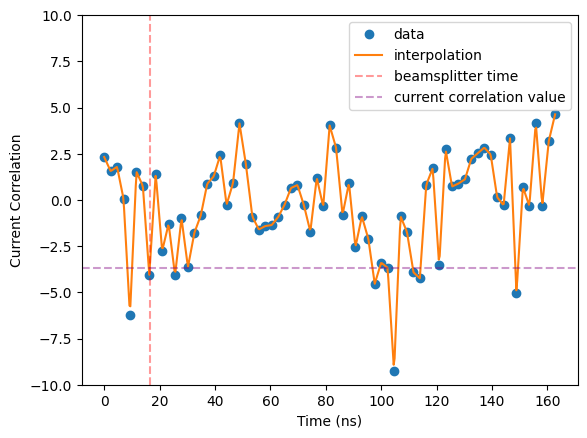

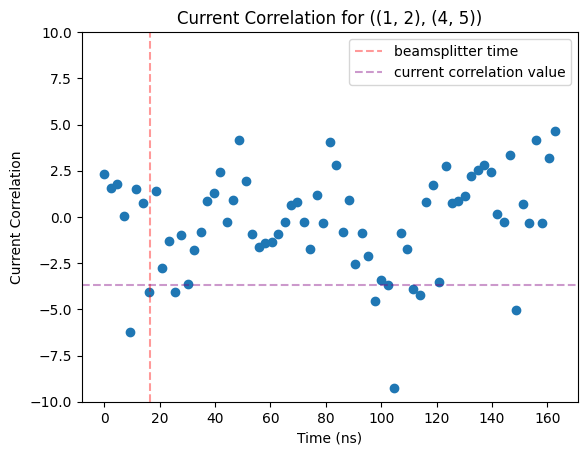

((1, 2), (5, 6)): beamsplitter_average: 19.4 ns


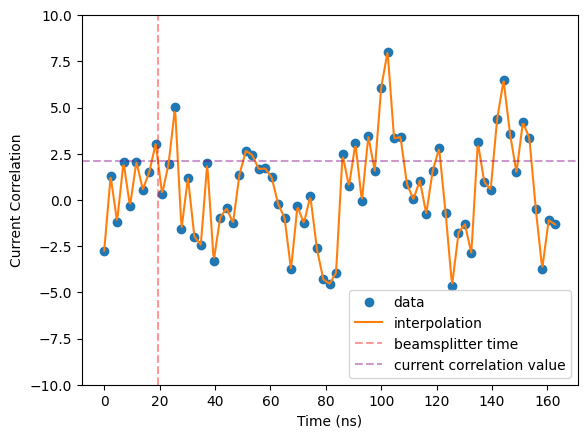

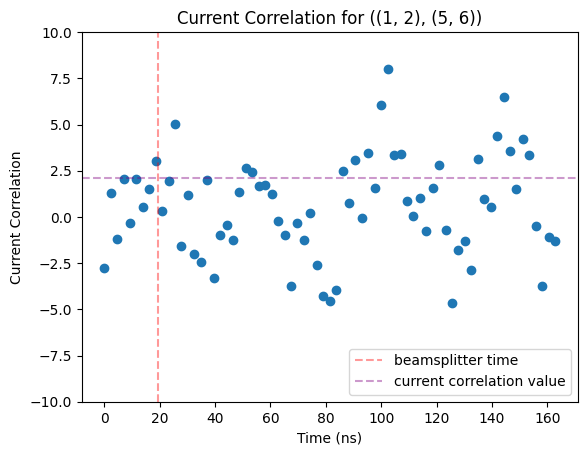

((1, 2), (6, 7)): beamsplitter_average: 18.51 ns


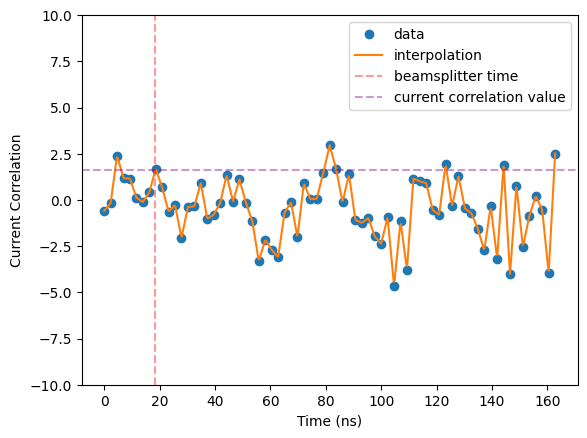

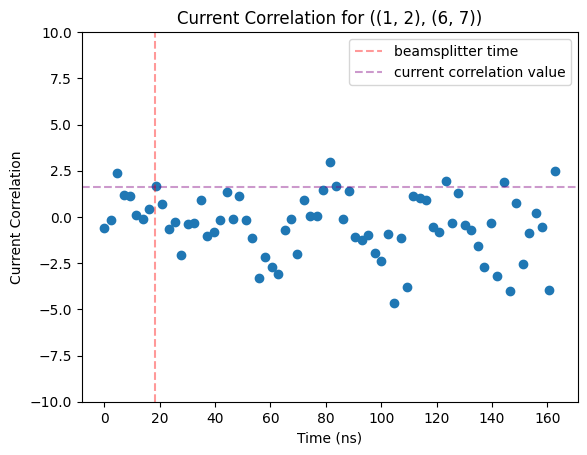

((1, 2), (7, 8)): beamsplitter_average: 28.48 ns


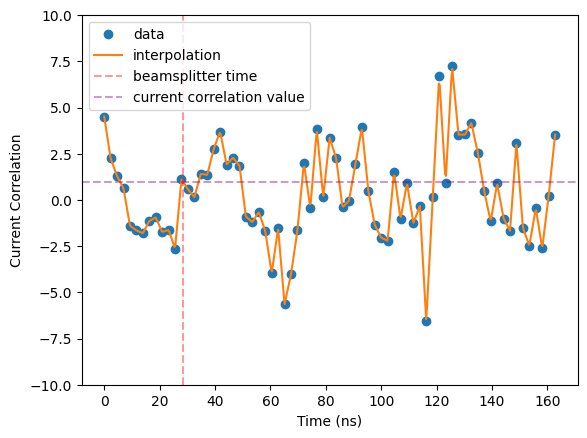

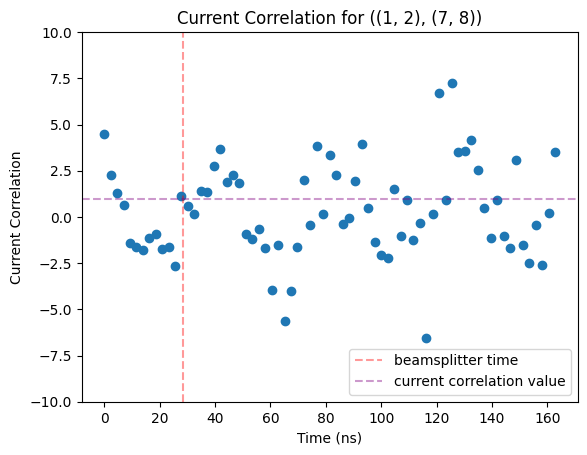

((2, 3), (4, 5)): beamsplitter_average: 21.68 ns


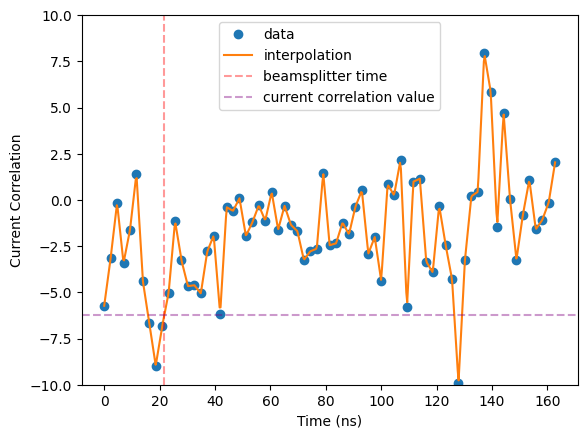

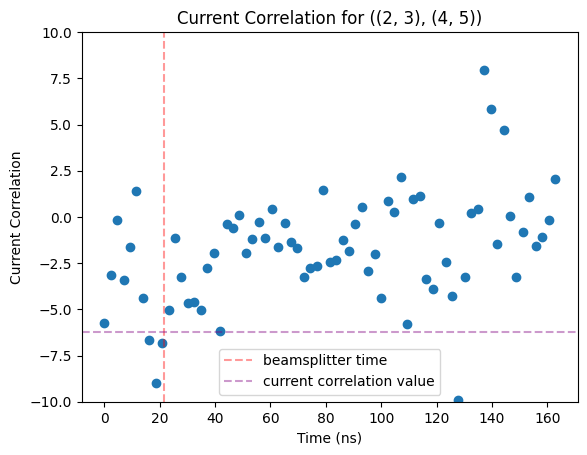

((2, 3), (5, 6)): beamsplitter_average: 17.29 ns


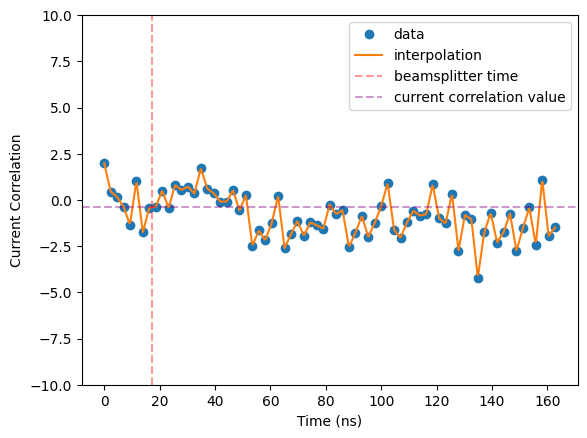

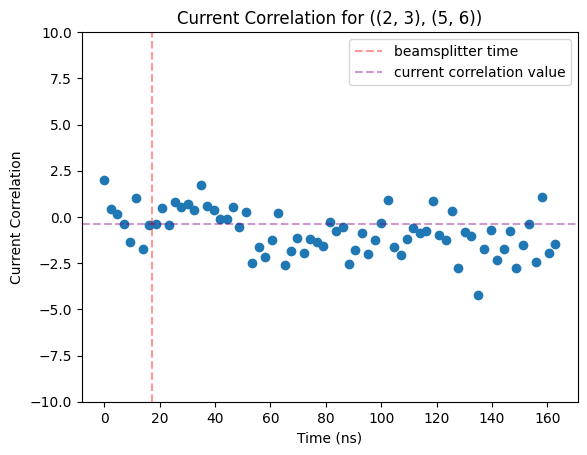

((2, 3), (6, 7)): beamsplitter_average: 23.27 ns


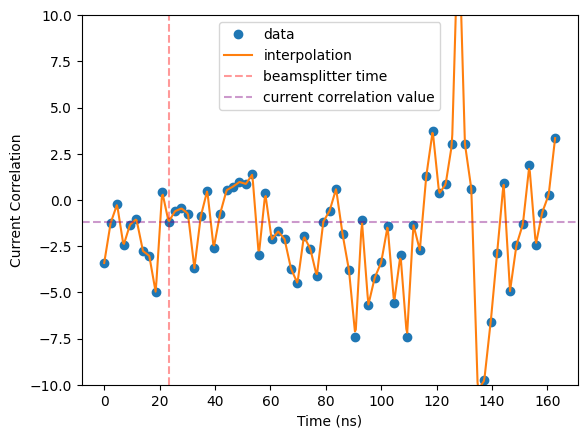

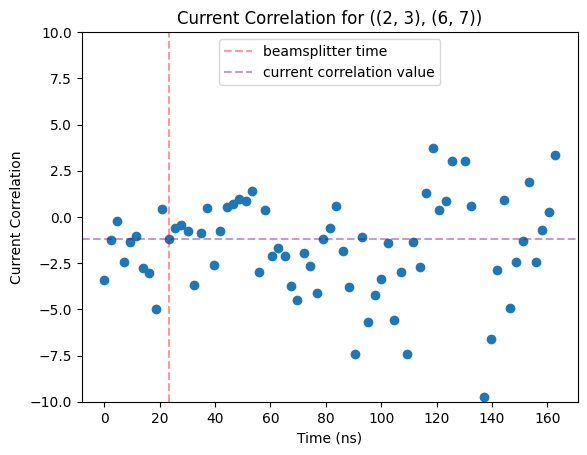

((2, 3), (7, 8)): beamsplitter_average: 15.21 ns


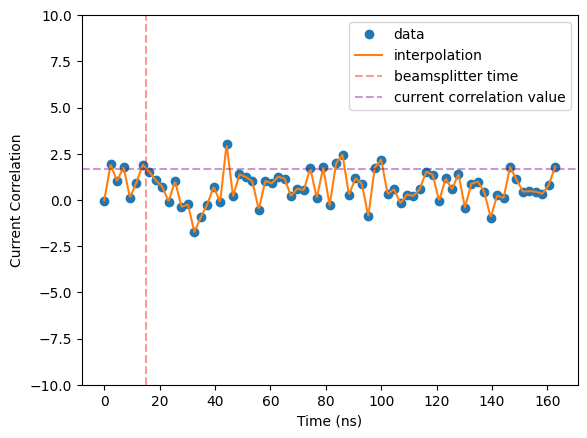

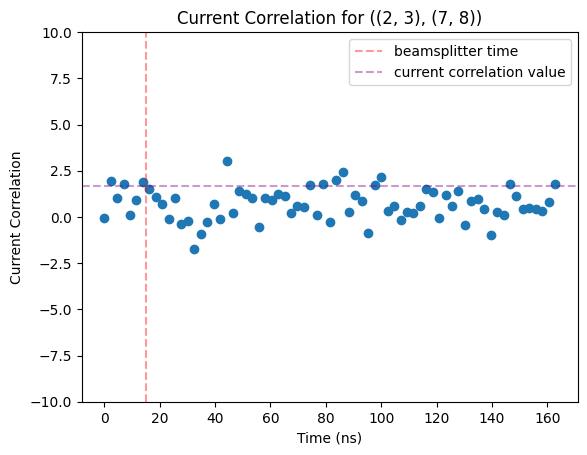

((3, 4), (5, 6)): beamsplitter_average: 18.83 ns


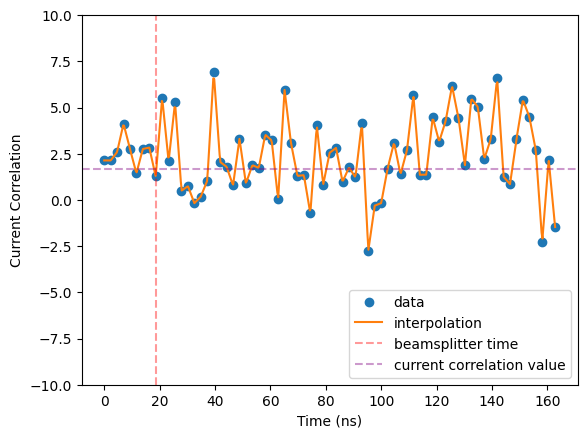

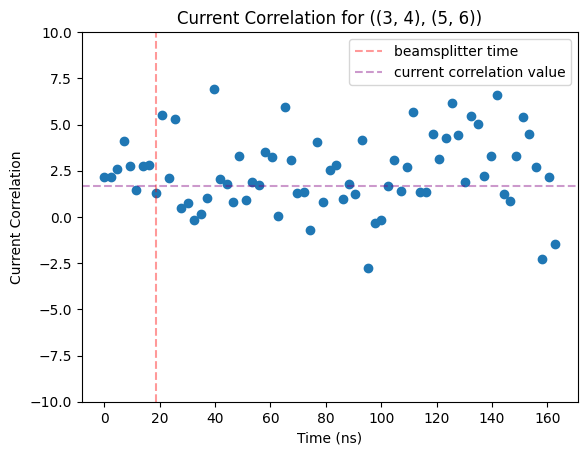

((3, 4), (6, 7)): beamsplitter_average: 18.62 ns


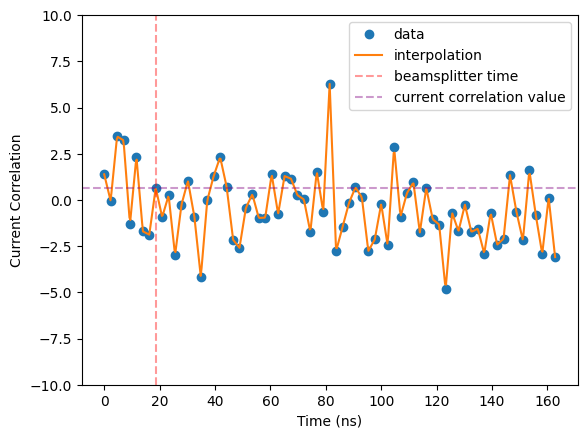

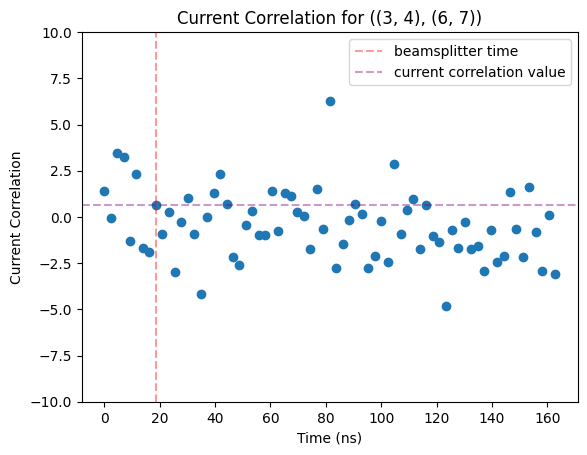

((3, 4), (7, 8)): beamsplitter_average: 19.12 ns


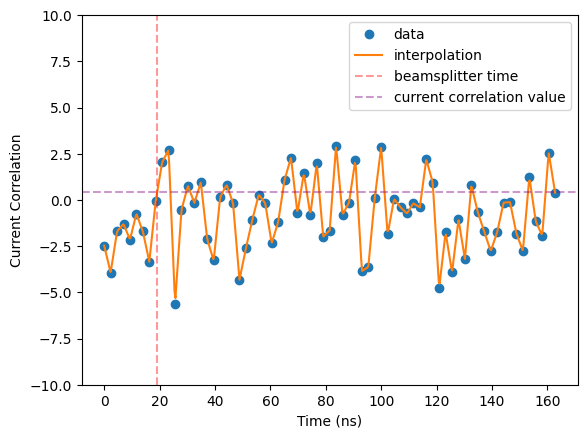

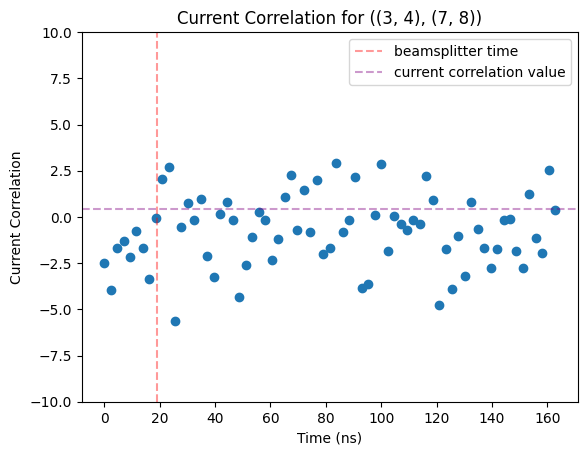

((4, 5), (6, 7)): beamsplitter_average: 23.12 ns


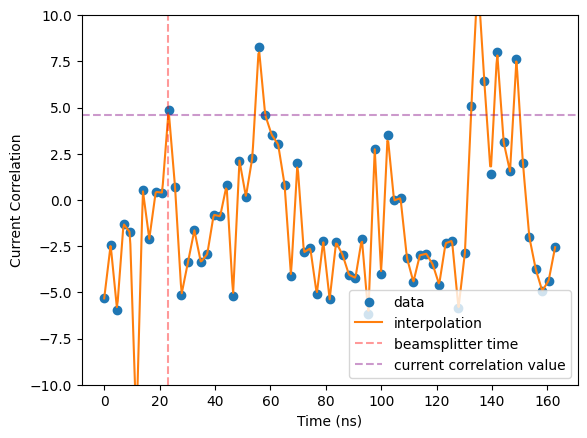

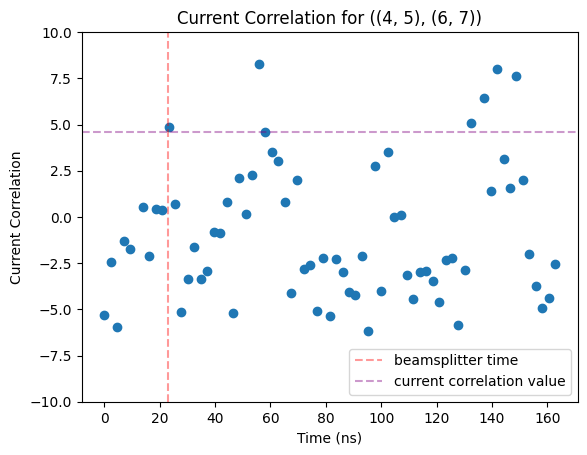

((4, 5), (7, 8)): beamsplitter_average: 15.09 ns


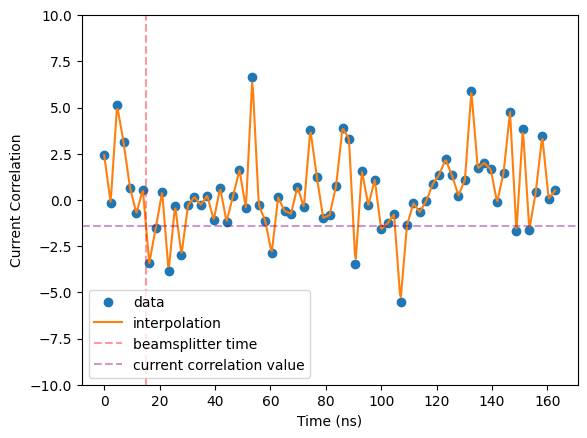

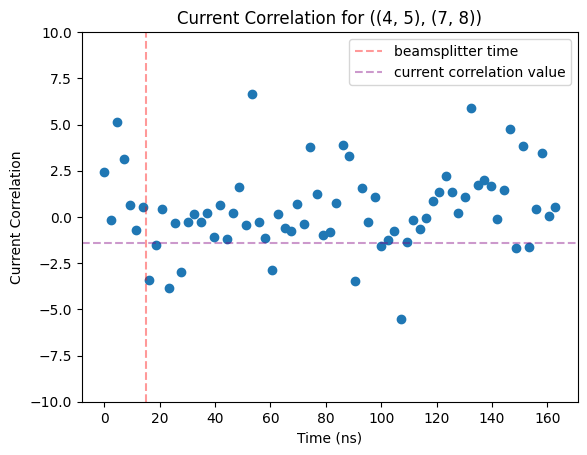

((5, 6), (7, 8)): beamsplitter_average: 19.26 ns


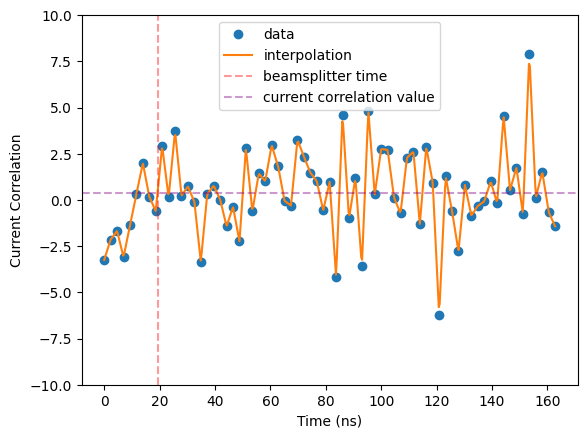

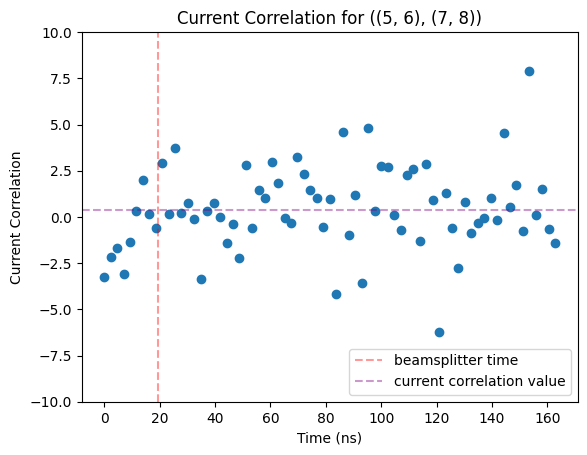

In [23]:
for correlation_pair in correlation_pairs:

    correlation_pair_data = data['data'][coupling_point]['highest'][str(correlation_pair)]
    current_correlation = correlation_pair_data['current_correlation']
    times = correlation_pair_data['times']

    beamsplitter_average = correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_average']

    print(f'{correlation_pair}: beamsplitter_average: {round(beamsplitter_average, 2)} ns')

    # value
    beamsplitter_index = np.argmin(np.abs(times - beamsplitter_average))

    current_correlation_value = current_correlation[beamsplitter_index]


    # error
    beamsplitter_average_error = correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_average_error']

    current_correlation_value, current_correlation_error = get_interpolation_value(times, current_correlation, beamsplitter_average, beamsplitter_average_error, plot_interpolation=True)

    correlation_pair_to_current_correlation_value[correlation_pair] = current_correlation_value
    correlation_pair_to_current_correlation_error[correlation_pair] = current_correlation_error

    plt.plot(times, current_correlation, linestyle='', marker='o')
    
    plt.axvline(x=beamsplitter_average, color='red', linestyle='--', label='beamsplitter time', alpha=0.4)
    plt.axhline(y=current_correlation_value, color='purple', linestyle='--', label='current correlation value', alpha=0.4)
    
    plt.xlabel('Time (ns)')
    plt.ylabel('Current Correlation')


    plt.ylim(-10, 10)

    plt.title(f'Current Correlation for {correlation_pair}')
    plt.legend()
    plt.show()

### 3.2 Plot vs Distance

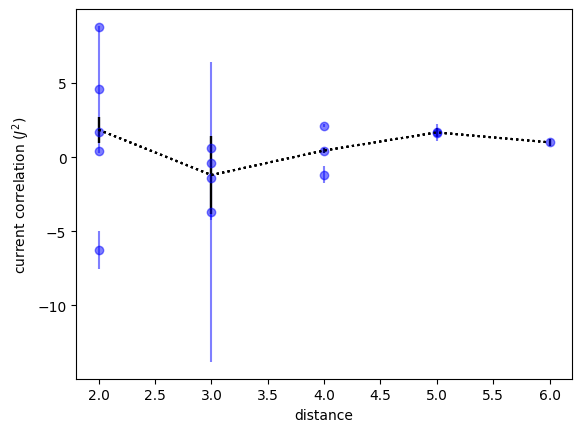

In [116]:
# plot current correlations values by distance

distances = list(range(2,7))
distance_to_correlation_value_list = {i: [] for i in distances}
distance_to_correlation_error_list = {i: [] for i in distances}

for correlation_pair in correlation_pairs:
    current_correlation_value = correlation_pair_to_current_correlation_value[correlation_pair]
    current_correlation_error = correlation_pair_to_current_correlation_error[correlation_pair]

    distance = abs(correlation_pair[0][0] - correlation_pair[1][0])

    distance_to_correlation_value_list[distance].append(current_correlation_value)
    distance_to_correlation_error_list[distance].append(current_correlation_error)


current_correlation_average_values = [np.mean(distance_to_correlation_value_list[distance]) for distance in distance_to_correlation_value_list]

current_correlation_average_errors = [np.sqrt(np.sum(np.array(distance_to_correlation_error_list[distance])**2)) / len(distance_to_correlation_error_list[distance]) for distance in distance_to_correlation_error_list]

current_correlation_total = sum(current_correlation_average_values)

current_correlation_total_error = np.sqrt(np.sum(np.array(current_correlation_average_errors)**2))

for distance in distances:
    values = distance_to_correlation_value_list[distance]

    plt.errorbar([distance]*len(values), values, yerr=distance_to_correlation_error_list[distance], marker='o', linestyle='', color='blue', alpha=0.5)

    plt.errorbar(distances, current_correlation_average_values, yerr=current_correlation_average_errors, linestyle=':', color='black', alpha=0.8)

plt.xlabel('distance')
plt.ylabel('current correlation ($J^2$)')

plt.show()


### 3.3 Save Data

In [117]:
data_dictionary = {}

for correlation_pair in correlation_pairs:

    correlation_pair_data = data['data'][coupling_point]['highest'][str(correlation_pair)]

    correlation_pair_data['current_correlation_value'] = float(correlation_pair_to_current_correlation_value[correlation_pair])
    correlation_pair_data['current_correlation_error'] = float(correlation_pair_to_current_correlation_error[correlation_pair])


    correlation_pair_data['beamsplitter_time'] = correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_average']
    correlation_pair_data['beamsplitter_time_error'] = correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_average_error']

    data_dictionary[correlation_pair] = correlation_pair_data


data_dictionary['distances'] = distances
data_dictionary['current_correlation_averages'] = current_correlation_average_values
data_dictionary['current_correlation_average_errors'] = current_correlation_average_errors

data_dictionary['distance_to_current_correlation_value'] = distance_to_correlation_value_list
data_dictionary['distance_to_current_correlation_error'] = distance_to_correlation_error_list

data_dictionary['current_correlation_total'] = current_correlation_total
data_dictionary['current_correlation_total_error'] = current_correlation_total_error



In [118]:
print(data_dictionary.keys())

dict_keys([((1, 2), (3, 4)), ((1, 2), (4, 5)), ((1, 2), (5, 6)), ((1, 2), (6, 7)), ((1, 2), (7, 8)), ((2, 3), (4, 5)), ((2, 3), (5, 6)), ((2, 3), (6, 7)), ((2, 3), (7, 8)), ((3, 4), (5, 6)), ((3, 4), (6, 7)), ((3, 4), (7, 8)), ((4, 5), (6, 7)), ((4, 5), (7, 8)), ((5, 6), (7, 8)), 'distances', 'current_correlation_averages', 'current_correlation_average_errors', 'distance_to_current_correlation_value', 'distance_to_current_correlation_error', 'current_correlation_total', 'current_correlation_total_error'])


In [119]:
data_filename = 'current_correlations_data.h5'

eigenstate = 'highest'

keys = ('data', coupling_point, eigenstate)

update_data_file(data_filename, data_dictionary, keys=keys, save_backup=True)

In [120]:
for correlation_pair in correlation_pairs:
    if 'beamsplitter_fit' in coupling_point_config['data_config'][str(correlation_pair)]:
        print(f'{correlation_pair}: {coupling_point_config["data_config"][str(correlation_pair)]["beamsplitter_fit"]}')
    else:
        print(f'{correlation_pair}: disordered')

((1, 2), (3, 4)): coupling
((1, 2), (4, 5)): disordered_2
((1, 2), (5, 6)): coupling
((1, 2), (6, 7)): disordered
((1, 2), (7, 8)): disordered
((2, 3), (4, 5)): disordered_2
((2, 3), (5, 6)): disordered_2
((2, 3), (6, 7)): disordered_2
((2, 3), (7, 8)): disordered_2
((3, 4), (5, 6)): coupling
((3, 4), (6, 7)): coupling
((3, 4), (7, 8)): coupling
((4, 5), (6, 7)): disordered
((4, 5), (7, 8)): disordered
((5, 6), (7, 8)): coupling
